# CPMK 1

Fuzzy Logic-Based Expert System for Adaptive Cruise Control in cars 
Modern vehicles are equipped with Adaptive Cruise Control (ACC) systems designed to automatically 
adjust the vehicle’s speed to maintain a safe distance from the car ahead. A fuzzy logic controller can be 
implemented to make smooth, human-like decisions based on the current traffic situation. 
The controller uses the minimum of three inputs variables: 
- Input 1: Distance (D) - the distance to the vehicle ahead (in meters). 
- Input 2: Relative Speed (ΔV) – the speed difference between our car and the vehicle ahead (in km/h). 
- Input 3: Road Slope (S) — the inclination of the road (in degrees), where positive values represent uphill 
and negative values represent downhill conditions. 
- Output: Acceleration Command (A) – determines whether the vehicle should accelerate, maintain speed, 
or decelerate. <br>
**a. Definition of Variables** <br>
Define the fuzzy linguistic variables and their corresponding fuzzy sets for each input and output. Provide 
appropriate membership functions and describe their ranges. <br>
**b. Rule Base Design** <br>
Construct at least nine (9) fuzzy IF–THEN rules that describe the decision-making behavior of the ACC 
system. Rules must reflect realistic driving behavior and safe operation. <br>
**c. Evaluation and Discussion** <br>
Interpret the resulting output. <br>
- Does the system’s decision align with real-world driving logic? 
- Explain how fuzzy logic offers a more flexible and human-like control behavior compared to 
traditional threshold-based systems.

In [2]:
import numpy as np

# -------- Membership helpers --------

def trapmf(x, a, b, c, d):
    # Trapezoidal MF: 0 for x<=a, ramps to 1 between a-b, stays 1 b-c, ramps down c-d, 0 after d
    return np.maximum(
        np.minimum((x - a) / (b - a), 1.0, (d - x) / (d - c)),
        0.0
    )

def trimf(x, a, b, c):
    # Triangular MF: 0 outside [a,c], linear up a-b, linear down b-c
    return np.maximum(np.minimum((x - a) / (b - a), (c - x) / (c - b)), 0.0)

# -------- Input membership functions --------

def mu_D_near(D):
    # Near: trapezoid ~ [0,10,10,30]
    if D <= 10: return 1.0
    if 10 < D < 30: return (30 - D) / 20.0
    return 0.0

def mu_D_medium(D):
    # Medium: triangle ~ [20,50,80] (center ~50)
    return trimf(D, 20.0, 50.0, 80.0)

def mu_D_far(D):
    # Far: trapezoid ~ [60,100,200,200] simplified to ramp after 60
    if D <= 60: return 0.0
    if 60 < D < 100: return (D - 60) / 40.0
    return 1.0

def mu_dV_OF(dV):  # Opening Fast (negative large)
    return trimf(dV, -40.0, -30.0, -10.0)

def mu_dV_O(dV):   # Opening (negative)
    return trimf(dV, -30.0, -15.0, 0.0)

def mu_dV_S(dV):   # Same (near zero), narrower
    return trimf(dV, -10.0, 0.0, 10.0)

def mu_dV_C(dV):   # Closing (positive)
    return trimf(dV, 0.0, 15.0, 30.0)

def mu_dV_CF(dV):  # Closing Fast (positive large)
    return trimf(dV, 10.0, 30.0, 40.0)

def mu_S_DH(S):    # Downhill
    # Left shoulder: 1 below -6, fade to 0 by -2
    if S <= -6: return 1.0
    if -6 < S < -2: return (-2 - S) / 4.0
    return 0.0

def mu_S_FL(S):    # Flat
    return trimf(S, -4.0, 0.0, 4.0)

def mu_S_UH(S):    # Uphill
    # Right shoulder: 0 below 2, ramp to 1 by 6
    if S <= 2: return 0.0
    if 2 < S < 6: return (S - 2) / 4.0
    return 1.0

In [3]:
 #-------- Output universe and membership functions --------

A_universe = np.linspace(-3.0, 2.0, 501)

def mu_A_SB(A):  # Strong Brake
    # Left shoulder ~ [-3.0, -2.5, -1.5]
    if A <= -2.5: return 1.0
    if -2.5 < A < -1.5: return (-1.5 - A) / 1.0
    return 0.0

def mu_A_B(A):   # Brake triangle center -1.5 width ~1.5
    return trimf(A, -3.0, -1.5, 0.0)

def mu_A_H(A):   # Hold near 0 narrow
    return trimf(A, -0.8, 0.0, 0.8)

def mu_A_AC(A):  # Accelerate ~ center 0.8 width 0.8
    return trimf(A, 0.0, 0.8, 1.6)

def mu_A_SAC(A): # Strong Accelerate right shoulder ~ [1.0, 2.0]
    if A <= 1.0: return 0.0
    if 1.0 < A < 2.0: return (A - 1.0) / 1.0
    return 1.0

# Map output label -> MF function over A_universe
OUTPUT_MFS = {
    'SB': np.vectorize(mu_A_SB),
    'B':  np.vectorize(mu_A_B),
    'H':  np.vectorize(mu_A_H),
    'AC': np.vectorize(mu_A_AC),
    'SAC':np.vectorize(mu_A_SAC)
}


In [4]:
# -------- Rule base --------
# Each rule: (antecedent function, output label)

def antecedent_strength(D, dV, S, D_label, dV_label, S_label=None):
    # Compute degree for (D is D_label) AND (dV is dV_label) AND optionally (S is S_label)
    D_mf = {'N': mu_D_near, 'M': mu_D_medium, 'F': mu_D_far}[D_label](D)
    dV_mf = {'OF': mu_dV_OF, 'O': mu_dV_O, 'S': mu_dV_S, 'C': mu_dV_C, 'CF': mu_dV_CF}[dV_label](dV)
    if S_label is None:
        return min(D_mf, dV_mf)
    S_mf = {'DH': mu_S_DH, 'FL': mu_S_FL, 'UH': mu_S_UH}[S_label](S)
    return min(D_mf, dV_mf, S_mf)

RULES = [
    # Core safety
    (lambda D,dV,S: antecedent_strength(D,dV,S,'N','CF'), 'SB'),
    (lambda D,dV,S: antecedent_strength(D,dV,S,'N','C'),  'B'),
    (lambda D,dV,S: antecedent_strength(D,dV,S,'N','S'),  'B'),

    # Medium gap modulated by slope
    (lambda D,dV,S: antecedent_strength(D,dV,S,'M','C','DH'), 'B'),
    (lambda D,dV,S: antecedent_strength(D,dV,S,'M','C','FL'), 'H'),
    (lambda D,dV,S: antecedent_strength(D,dV,S,'M','C','UH'), 'H'),

    # Same speed contextual
    (lambda D,dV,S: antecedent_strength(D,dV,S,'M','S','DH'), 'B'),
    (lambda D,dV,S: antecedent_strength(D,dV,S,'M','S','UH'), 'AC'),

    # Far gap behaviors
    (lambda D,dV,S: antecedent_strength(D,dV,S,'F','O'),  'H'),
    (lambda D,dV,S: antecedent_strength(D,dV,S,'F','OF'), 'SAC'),
    (lambda D,dV,S: antecedent_strength(D,dV,S,'F','S','UH'), 'AC'),
    (lambda D,dV,S: antecedent_strength(D,dV,S,'F','C'),  'H'),
]


In [5]:
# -------- Inference engine --------

def acc_command(D, dV, S):
    """
    Compute acceleration command A (m/s^2) for inputs:
    D : distance to lead (m), typical 0..200
    dV: relative speed (km/h), ego - lead, negative=open, positive=closing
    S : road slope (deg), negative=downhill, positive=uphill
    Returns: float A in [-3.0, 2.0]
    """
    # Initialize aggregated output MF (zeros over A_universe)
    agg = np.zeros_like(A_universe)

    # Fire each rule, clip output MF by firing strength, then aggregate via max
    for ant, out_label in RULES:
        strength = ant(D, dV, S)  # scalar in [0,1]
        if strength <= 0.0:
            continue
        out_mf_vals = OUTPUT_MFS[out_label](A_universe)  # vector over A_universe
        clipped = np.minimum(out_mf_vals, strength)
        agg = np.maximum(agg, clipped)

    # If no rule fired, default to Hold
    if np.all(agg == 0.0):
        agg = OUTPUT_MFS['H'](A_universe)
        # Centroid defuzzification
    numerator = np.trapezoid(agg * A_universe, A_universe)
    denominator = np.trapezoid(agg, A_universe)
    if denominator == 0:
        return 0.0
    A = numerator / denominator

    # Clip to actuator limits
    return float(np.clip(A, -3.0, 2.0))

In [6]:
# -------- Demo --------
if __name__ == "__main__":
    scenarios = [
        # (D, dV, S, description)
        (45.0, 12.0, -3.0, "Medium gap, closing, slight downhill"),
        (110.0, -20.0, 0.0, "Far gap, opening, flat"),
        (25.0, 18.0, 0.0, "Near, closing, flat"),
        (80.0, 0.0, 5.0, "Medium/Far, same speed, uphill"),
        (60.0, -5.0, -6.0, "Medium, slight opening, steep downhill"),
    ]
    for D, dV, S, desc in scenarios:
        A = acc_command(D, dV, S)
        print(f"{desc}: D={D} m, dV={dV} km/h, S={S} deg -> A={A:.3f} m/s^2")

Medium gap, closing, slight downhill: D=45.0 m, dV=12.0 km/h, S=-3.0 deg -> A=-1.057 m/s^2
Far gap, opening, flat: D=110.0 m, dV=-20.0 km/h, S=0.0 deg -> A=0.556 m/s^2
Near, closing, flat: D=25.0 m, dV=18.0 km/h, S=0.0 deg -> A=-1.272 m/s^2
Medium/Far, same speed, uphill: D=80.0 m, dV=0.0 km/h, S=5.0 deg -> A=0.800 m/s^2
Medium, slight opening, steep downhill: D=60.0 m, dV=-5.0 km/h, S=-6.0 deg -> A=-1.500 m/s^2


# CPMK 2

2. Linear Regression Design for Vehicle Fuel Efficiency Prediction Automotive engineers aim to improve fuel efficiency (measured in km per liter) by analyzing the relationships between vehicle design parameters and performance factors. You are assigned to develop a linear regression model to predict the fuel efficiency (Y) of a vehicle based on several influencing variables. 
   
   You may collect or download your own dataset from a reliable source such as: 
- Kaggle: Vehicle Fuel Efficiency / MPG Dataset 
- UCI Machine Learning Repository: Auto MPG Dataset 
- or other open datasets with relevant attributes. 
  
  a. Data Preprocessing 
	- Perform data cleaning (handle missing values, remove duplicates, and correct data types). 
	- Conduct data transformation, such as normalization, encoding categorical variables, or scaling numerical values. 
  
  b. Model Development 
	- Split the dataset into training and testing subsets (e.g., 80%–20%). 
	- Train a Linear Regression model using the selected features. 

  c. Model Evaluation 
  - Evaluate the model using performance metrics, such as: 
	  - Mean Absolute Error (MAE)
	  - Mean Squared Error (MSE) 
	  - Root Mean Squared Error (RMSE) 
	  - R² Score 
  - Discuss the performance results and explain whether the model fits the data well. 
  
  d. Interpret the final result on what factors most influence vehicle fuel efficiency?

Dataset used: https://www.kaggle.com/datasets/makslypko/large-cars-dataset<br>
Reasons:
1. Includes physical dimensions such as weight, wheelbase, engine size and total length, which are one of the important factors for predicting fuel consumption

### 1. Data Preprocessing

In [7]:
# Read car dataset
import pandas as pd
df = pd.read_csv("car_dataset.csv")

In [8]:
df.sample(10)

,Brand,Model,VehicleClass,Region,DriveTrain,MSRP,DealerCost,EngineSize,Cylinders,HorsePower,MPG_City,MPG_Highway,Weight,Wheelbase,Length
226,Lexus,LS 430 4dr,Sedan,Asia,Rear,"$55,750","$48,583",4.3,8.0,290,18,25,3990,115,197
105,Dodge,Durango SLT,SUV,USA,All,"$32,235","$29,472",4.7,8.0,230,15,21,4987,119,201
139,Ford,Focus ZTW,Wagon,USA,Front,"$17,475","$16,375",2.0,4.0,130,26,33,2702,103,178
267,Mercedes-Benz,S430 4dr,Sedan,Europe,Rear,"$74,320","$69,168",4.3,8.0,275,18,26,4160,122,203
420,Volvo,S60 R 4dr,Sedan,Europe,All,"$37,560","$35,382",2.5,5.0,300,18,25,3571,107,181
222,Lexus,IS 300 4dr manual,Sedan,Asia,Rear,"$31,045","$27,404",3.0,6.0,215,18,25,3255,105,177
368,Suzuki,Aerio LX 4dr,Sedan,Asia,Front,"$14,500","$14,317",2.3,4.0,155,25,31,2676,98,171
394,Toyota,Sienna XLE Limited,Sedan,Asia,Front,"$28,800","$25,690",3.3,6.0,230,19,27,4165,119,200
286,Mitsubishi,Endeavor XLS,SUV,Asia,All,"$30,492","$28,330",3.8,6.0,215,17,21,4134,109,190
264,Mercedes-Benz,CLK500 coupe 2dr (convertible),Sedan,Europe,Rear,"$52,800","$49,104",5.0,8.0,302,17,22,3585,107,183


In [9]:
dimension = df.shape
print("Jumlah row:", dimension[0])
print("Jumlah column:", dimension[1])

Jumlah row: 428
Jumlah column: 15


In [10]:
df.info() # info data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         428 non-null    object 
 1   Model         428 non-null    object 
 2   VehicleClass  428 non-null    object 
 3   Region        428 non-null    object 
 4   DriveTrain    428 non-null    object 
 5   MSRP          428 non-null    object 
 6   DealerCost    428 non-null    object 
 7   EngineSize    428 non-null    float64
 8   Cylinders     426 non-null    float64
 9   HorsePower    428 non-null    int64  
 10  MPG_City      428 non-null    int64  
 11  MPG_Highway   428 non-null    int64  
 12  Weight        428 non-null    int64  
 13  Wheelbase     428 non-null    int64  
 14  Length        428 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 50.3+ KB


In [11]:
df.isnull().sum() # check missing value in each column

Brand           0
Model           0
VehicleClass    0
Region          0
DriveTrain      0
MSRP            0
DealerCost      0
EngineSize      0
Cylinders       2
HorsePower      0
MPG_City        0
MPG_Highway     0
Weight          0
Wheelbase       0
Length          0
dtype: int64

In [12]:
df[df.isnull().any(axis=1)] # show null rows

,Brand,Model,VehicleClass,Region,DriveTrain,MSRP,DealerCost,EngineSize,Cylinders,HorsePower,MPG_City,MPG_Highway,Weight,Wheelbase,Length
247,Mazda,RX-8 4dr automatic,Sports,Asia,Rear,"$25,700","$23,794",1.3,NaN,197,18,25,3053,106,174
248,Mazda,RX-8 4dr manual,Sports,Asia,Rear,"$27,200","$25,179",1.3,NaN,238,18,24,3029,106,174


Important distinction: Mazda RX series uses Rotary (Wankel) engine, hence why the cylinders are labelled as NaN because Rotary is powered by triangular rotor spinning instead of pistons which has cylinders.

Fun fact: Rotary engine actually performs worse in fuel efficiency since its configuration allows for more power compared to traditional engine at similar dimension by allowing more combustions without large engine size.

In [13]:
df = df.dropna(subset=["Cylinders"]) # drop null rows (rotary engine cars)

In [14]:
df.isnull().sum() # check missing value in each column

Brand           0
Model           0
VehicleClass    0
Region          0
DriveTrain      0
MSRP            0
DealerCost      0
EngineSize      0
Cylinders       0
HorsePower      0
MPG_City        0
MPG_Highway     0
Weight          0
Wheelbase       0
Length          0
dtype: int64

In [15]:
df[df.duplicated()] # check for duplicate data

,Brand,Model,VehicleClass,Region,DriveTrain,MSRP,DealerCost,EngineSize,Cylinders,HorsePower,MPG_City,MPG_Highway,Weight,Wheelbase,Length


In [16]:
df.columns # check the column names

Index(['Brand', 'Model', 'VehicleClass', 'Region', 'DriveTrain', 'MSRP',
       'DealerCost', 'EngineSize', 'Cylinders', 'HorsePower', 'MPG_City',
       'MPG_Highway', 'Weight', 'Wheelbase', 'Length'],
      dtype='object')

### 2. Data Visualization

1. Target definition:
km/L isn't there, so we'll need to compute combined MPG (0.55 * city + 0.45 * highway) * 0.425 to get one
2. Categoricals:
Vehicle Class and Drivetrain affects fuel economy too. One hot encode them
3. Features might be used:
- EngineSize, HorsePower, Weight, Wheelbase, Length, Cylinders (continuous)
- VehicleClass, DriveTrain (categorical)
- Fuel EFficiency (km/L)

To predict fuel efficiency, when user input enginesize, horsepower, weight, wheelbase, length, cylinders, vehicle class, drivetrain, it will output x km/L
Example: 2.7L 300hp 2500kg 130 170 5.0L SUV 4WD will get 12km/L

In [17]:
from matplotlib import pyplot as plt
import seaborn as sns

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 426 entries, 0 to 427
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         426 non-null    object 
 1   Model         426 non-null    object 
 2   VehicleClass  426 non-null    object 
 3   Region        426 non-null    object 
 4   DriveTrain    426 non-null    object 
 5   MSRP          426 non-null    object 
 6   DealerCost    426 non-null    object 
 7   EngineSize    426 non-null    float64
 8   Cylinders     426 non-null    float64
 9   HorsePower    426 non-null    int64  
 10  MPG_City      426 non-null    int64  
 11  MPG_Highway   426 non-null    int64  
 12  Weight        426 non-null    int64  
 13  Wheelbase     426 non-null    int64  
 14  Length        426 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 53.2+ KB


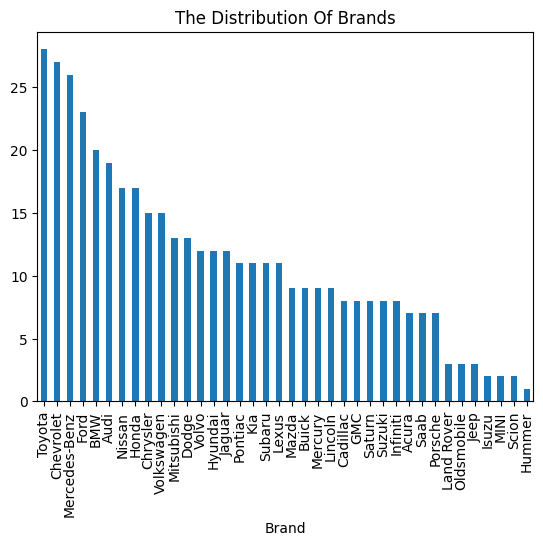

In [18]:
df['Brand'].value_counts().plot.bar()
plt.title("The Distribution Of Brands")
plt.show()

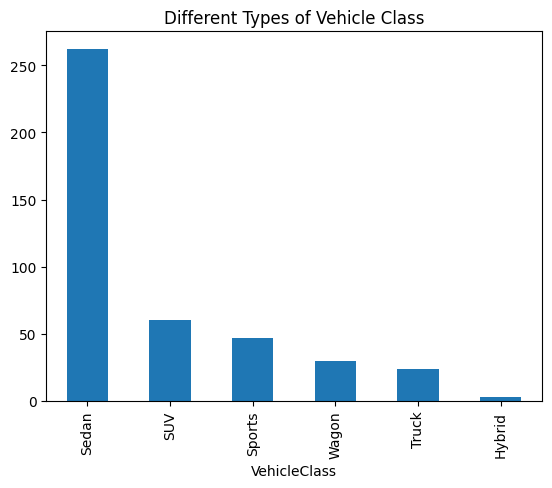

In [19]:
df['VehicleClass'].value_counts().plot.bar()
plt.title("Different Types of Vehicle Class")
plt.show()

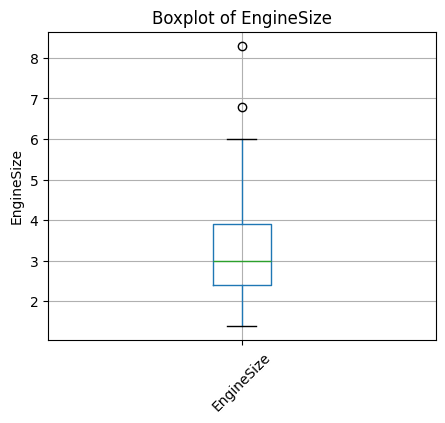

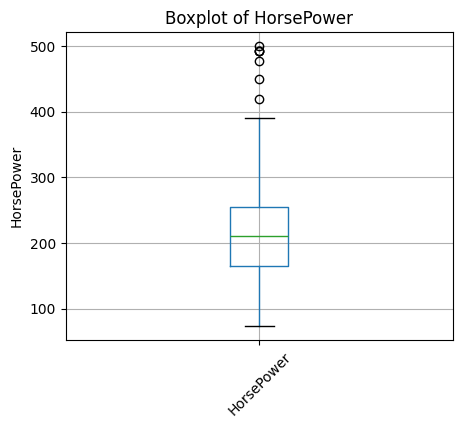

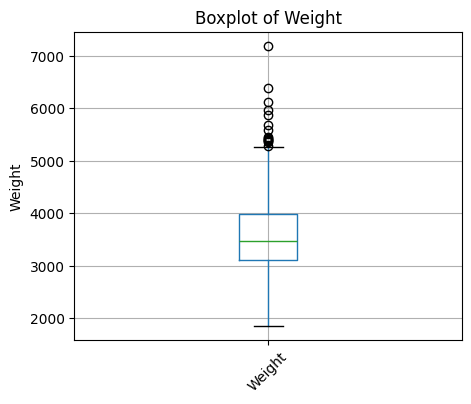

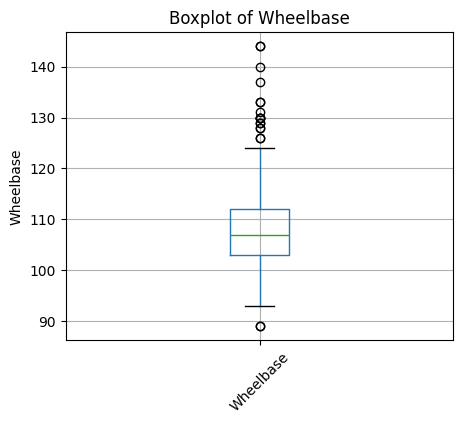

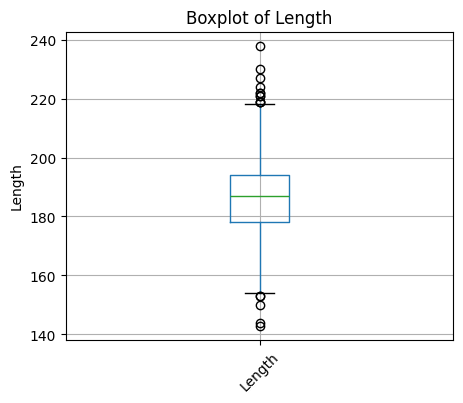

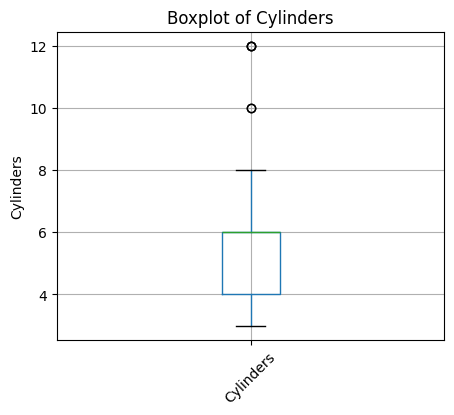

In [20]:
# List of continuous features
features = ['EngineSize', 'HorsePower', 'Weight', 'Wheelbase', 'Length', 'Cylinders']

# Loop through each feature and plot individually
for col in features:
    plt.figure(figsize=(5,4))
    df.boxplot(column=[col])
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.show()

In [39]:
# Top 10 highest HP
top_hp = df.nlargest(10, "HorsePower")

tabel_hp = top_hp[[
    "Brand", "Model", "VehicleClass", "EngineSize",
    "Cylinders", "HorsePower", "Weight", "MPG_City", "MPG_Highway"
]]

print(tabel_hp.to_string(index=False))


        Brand                        Model VehicleClass  EngineSize  Cylinders  HorsePower  Weight  MPG_City  MPG_Highway
        Dodge Viper SRT-10 convertible 2dr       Sports         8.3       10.0         500    3410        12           20
Mercedes-Benz                    CL600 2dr        Sedan         5.5       12.0         493    4473        13           19
Mercedes-Benz                 SL55 AMG 2dr       Sports         5.5        8.0         493    4235        14           21
Mercedes-Benz        SL600 convertible 2dr       Sports         5.5       12.0         493    4429        13           19
      Porsche                  911 GT2 2dr       Sports         3.6        6.0         477    3131        17           24
         Audi                     RS 6 4dr       Sports         4.2        8.0         450    4024        15           22
   Volkswagen              Phaeton W12 4dr        Sedan         6.0       12.0         420    5399        12           19
       Jaguar           

In [40]:
# Top 10 highest highway MPG
top_mpg = df.nlargest(10, "MPG_Highway")

tabel_mpg = top_mpg[[
    "Brand", "Model", "VehicleClass", "EngineSize",
    "Cylinders", "HorsePower", "Weight", "MPG_City", "MPG_Highway"
]]

print(tabel_mpg.to_string(index=False))

     Brand                                  Model VehicleClass  EngineSize  Cylinders  HorsePower  Weight  MPG_City  MPG_Highway
     Honda             Insight 2dr (gas/electric)       Hybrid         2.0        3.0          73    1850        60           66
     Honda Civic Hybrid 4dr manual (gas/electric)       Hybrid         1.4        4.0          93    2732        46           51
    Toyota               Prius 4dr (gas/electric)       Hybrid         1.5        4.0         110    2890        59           51
Volkswagen                      Jetta GLS TDI 4dr        Sedan         1.9        4.0         100    3003        38           46
     Honda                           Civic HX 2dr        Sedan         1.7        4.0         117    2500        36           44
    Toyota                        Echo 2dr manual        Sedan         1.5        4.0         108    2035        35           43
    Toyota                               Echo 4dr        Sedan         1.5        4.0         108

<Axes: >

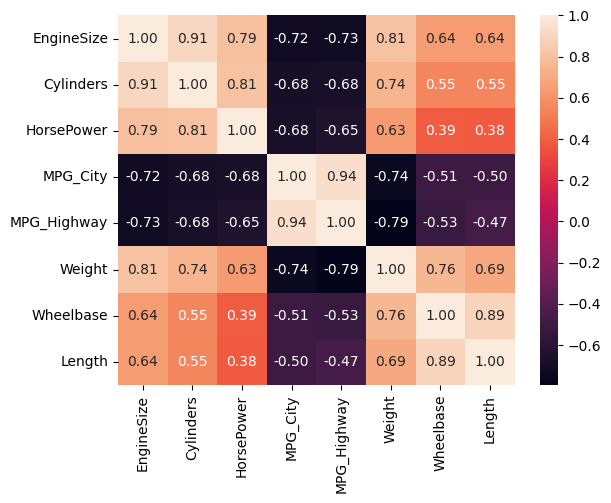

In [21]:
numeric_cols= df.select_dtypes(include=['number'])
corr_mat=numeric_cols.corr()
sns.heatmap(corr_mat,annot=True, fmt='.2f')

### 3. Data Preparation

In [22]:
df # get overall table

,Brand,Model,VehicleClass,Region,DriveTrain,MSRP,DealerCost,EngineSize,Cylinders,HorsePower,MPG_City,MPG_Highway,Weight,Wheelbase,Length
0,Acura,MDX,SUV,Asia,All,"$36,945","$33,337",3.5,6.0,265,17,23,4451,106,189
1,Acura,RSX Type S 2dr,Sedan,Asia,Front,"$23,820","$21,761",2.0,4.0,200,24,31,2778,101,172
2,Acura,TSX 4dr,Sedan,Asia,Front,"$26,990","$24,647",2.4,4.0,200,22,29,3230,105,183
3,Acura,TL 4dr,Sedan,Asia,Front,"$33,195","$30,299",3.2,6.0,270,20,28,3575,108,186
4,Acura,3.5 RL 4dr,Sedan,Asia,Front,"$43,755","$39,014",3.5,6.0,225,18,24,3880,115,197
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
423,Volvo,C70 LPT convertible 2dr,Sedan,Europe,Front,"$40,565","$38,203",2.4,5.0,197,21,28,3450,105,186
424,Volvo,C70 HPT convertible 2dr,Sedan,Europe,Front,"$42,565","$40,083",2.3,5.0,242,20,26,3450,105,186
425,Volvo,S80 T6 4dr,Sedan,Europe,Front,"$45,210","$42,573",2.9,6.0,268,19,26,3653,110,190
426,Volvo,V40,Wagon,Europe,Front,"$26,135","$24,641",1.9,4.0,170,22,29,2822,101,180


In [23]:
df["CombinedMPG"] = 0.55*df["MPG_City"] + 0.45*df["MPG_Highway"] # Create target prediction
df["FuelEfficiency_kmL"] = df["CombinedMPG"] * 0.425 # Convert both MPG to km/L
df["DisplacementPerCylinder"] = df["EngineSize"] / df["Cylinders"] # New feature: Displacement per Cylinder
df["PowerToWeight"] = df["HorsePower"] / df["Weight"]
df[['MPG_City', 'MPG_Highway', 'DisplacementPerCylinder', 'PowerToWeight', 'FuelEfficiency_kmL']].head()

,MPG_City,MPG_Highway,DisplacementPerCylinder,PowerToWeight,FuelEfficiency_kmL
0,17,23,0.583333,0.059537,8.37250
1,24,31,0.500000,0.071994,11.53875
2,22,29,0.600000,0.061920,10.68875
3,20,28,0.533333,0.075524,10.03000
4,18,24,0.583333,0.057990,8.79750


### 4. Build Model

In [24]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

num_cols = ["DisplacementPerCylinder", "HorsePower", "Weight", "Wheelbase", "Length", "PowerToWeight"]
cat_cols = ["VehicleClass", "DriveTrain"]
target = "FuelEfficiency_kmL"

X = df[num_cols + cat_cols]
y = df[target]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first"), cat_cols)
])

# --- 6. Ridge regression pipeline ---
ridge = Pipeline([
    ("prep", preprocess),
    ("reg", Ridge(alpha=1.0))
])

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# --- Train/Validation/Test split ---

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, shuffle=True
)
# (60% train, 20% val, 20% test)

# --- Fit model ---
ridge.fit(X_train, y_train)

# --- Evaluasi ---
r2_train = ridge.score(X_train, y_train)
r2_val   = ridge.score(X_val, y_val)
r2_test  = ridge.score(X_test, y_test)

print("Train R²:", r2_train)
print("Validation R²:", r2_val)
print("Test R²:", r2_test)


Train R²: 0.7721677380695519
Validation R²: 0.7569903653506949
Test R²: 0.7956342458269912


In [ ]:
# --- Example usage ---
spec = {
    "DisplacementPerCylinder": 0.45,
    "HorsePower": 300,
    "Weight": 2500,
    "Wheelbase": 130,
    "Length": 170,
    "PowerToWeight": 300/2500,
    "VehicleClass": "SUV",
    "DriveTrain": "All"
}

# Langsung print hasil prediksi
print("Predicted km/L:", ridge.predict(pd.DataFrame([spec]))[0])


Predicted km/L: 9.381972013989815
